# Earthquake and GNSS Analysis with Sage                                                                                                                                
  ### A Natural Language Science Notebook                                                                                                                                 
  This notebook demonstrates **Sage** (Science Agent) — a natural language infrastructure for scientific data exploration on the [National Data Platform (NDP)](https://nationaldataplatform.org). Every step, from data discovery to analysis, is expressed as a plain English prompt using the `%%ask` magic command, and results are returned in natural language with interactive maps and visualizations.                                                                                                                                        
  
  **What this notebook does:**
  1. Searches for significant earthquake events (M > 5) in the United States                                                                                              
  2. Discovers nearby GNSS/GPS station datasets from the NDP catalog                                                                                                      
  3. Downloads raw GNSS data from the closest station                                                                                                                     
  4. Analyzes the GNSS time series around the earthquake event

                                                                     
**Requirements:** Set your `NRP_API_KEY` in `_User-Persistent-Storage_CephBlock_/.env` before running it on NDP JupyterHub. 

In [1]:
%%ask                                                                                                                                                        
Find earthquake events with magnitude > 5 in the United States between 2024-12-03 and 2024-12-15.                                                                         
Summarize the results and save them as a GeoJSON file.

I'll help you find earthquake events with magnitude > 5 in the United States between those dates. Let me start by reading the USGS earthquake events skill to understand how to use it.

Now I understand how to use the USGS earthquake API. I'll query for earthquakes with magnitude > 5 in the United States between 2024-12-03 and 2024-12-15. I'll use a bounding box covering the continental US.

Found 1 earthquake matching the criteria. Now I'll create a Python script to process this data and save it as a formatted GeoJSON file.

## Summary

Found **1 earthquake** with magnitude > 5 in the United States between December 3-15, 2024:

| Property | Value |
|----------|-------|
| **Magnitude** | 5.7 |
| **Location** | Parker Butte, Nevada |
| **Date/Time** | 2024-12-09 at 23:08:31 UTC |
| **Depth** | 9.3 km |
| **Coordinates** | 39.17°N, -119.02°W |

**GeoJSON file saved to:**
`/home/jovyan/work/_User-Persistent-Storage_CephBlock_/Sage/_earthquake_gnss_sage_/earthquakes_usa_2024-12-03_to_2024-12-15.geojson`

The file contains the full feature with geometry, properties, and metadata ready for spatial analysis.

In [6]:
%%ask                                                                                                                                                       
Identify GPS station datasets located within 100 miles of this earthquake event in NDP,
and save these GPS stations as GeoJSON,
and report the distance between each GPS station and the corresponding earthquake.                                                                                          

I'll create a fresh script to identify GPS stations within exactly 100 miles of the earthquake and save them as GeoJSON.

I found 25 GNSS datasets but none had proper spatial coordinates. Let me check what spatial information is available in the previous search results.

Let me re-run the original search script to get the proper results.

Let me debug by examining the actual structure of search results to understand why coordinates aren't being found.

I see the issue - the spatial structure is different. Let me fix the script to use the correct structure.

## Summary: GPS Stations Within 100 Miles of Earthquake

**Earthquake Details:**
- **Magnitude:** M5.7
- **Date:** 2024-12-09
- **Location:** 39.1675°N, -119.0238°W (Parker Butte, Nevada)
- **Search Radius:** 100 miles (160.9 km)

**Results:**
Found **19 GPS stations** within 100 miles of the earthquake in the National Data Platform.

### Top 10 Stations (Sorted by Distance):

| Rank | Station ID | Distance (mi) | Distance (km) | Coordinates | Organization |
|------|-----------|---------------|---------------|-------------|--------------|
| 1 | P127.PW.LY_.00 | 38.38 | 61.77 | 39.50°N, -119.60°W | EarthScope Consortium |
| 2 | P142.PW.LY_.00 | 42.28 | 68.04 | 39.12°N, -119.81°W | EarthScope Consortium |
| 3 | P095.PW.LY_.00 | 45.78 | 73.67 | 39.70°N, -119.54°W | EarthScope Consortium |
| 4 | P143.PW.LY_.00 | 48.75 | 78.46 | 38.76°N, -119.76°W | EarthScope Consortium |
| 5 | P090.PW.LY_.00 | 50.02 | 80.51 | 39.57°N, -119.80°W | EarthScope Consortium |
| 6 | P150.PW.LY_.00 | 54.74 | 88.10 | 39.29°N, -120.03°W | EarthScope Consortium |
| 7 | P139.PW.LY_.00 | 63.28 | 101.85 | 39.91°N, -119.72°W | EarthScope Consortium |
| 8 | P146.PW.LY_.00 | 81.82 | 131.68 | 39.34°N, -120.54°W | EarthScope Consortium |
| 9 | P146.PB.LY_.40 | 81.82 | 131.68 | 39.34°N, -120.54°W | EarthScope Consortium |
| 10 | P147.PW.LY_.00 | 85.67 | 137.87 | 39.94°N, -120.28°W | EarthScope Consortium |

**Remaining stations (rank 11-19):** P640, P649, P627, P650, P140, P648, P632, P151, P308

### Summary Statistics:
- **Total stations found:** 19
- **Closest station:** P127.PW.LY_.00 at 38.38 miles
- **Furthest station:** P308.PW.LY_.00 at 97.99 miles
- **Organization:** All stations belong to EarthScope Consortium (Plate Boundary Observatory network)

### Output Files:
- **GeoJSON:** `gps_stations_within_100miles.geojson` - Complete spatial data with geometry and metadata
- **CSV:** `gps_stations_within_100miles.csv` - Tabular format with distance calculations

All files saved to: `/home/jovyan/work/_User-Persistent-Storage_CephBlock_/Sage/_earthquake_gnss_sage_/`

,rank,dataset_name,title,distance_km,distance_miles,station_lat,station_lon,organization,ckan_url
0,1,p127-pw-ly-00,P127.PW.LY_.00,61.77,38.38,39.499213,-119.599928,earthscope_consortium,https://nationaldataplatform.org/catalog/datas...
1,2,p142-pw-ly-00,P142.PW.LY_.00,68.04,42.28,39.123532,-119.810721,earthscope_consortium,https://nationaldataplatform.org/catalog/datas...
2,3,p095-pw-ly-00,P095.PW.LY_.00,73.67,45.78,39.698430,-119.536908,earthscope_consortium,https://nationaldataplatform.org/catalog/datas...
3,4,p143-pw-ly-00,P143.PW.LY_.00,78.46,48.75,38.760166,-119.764840,earthscope_consortium,https://nationaldataplatform.org/catalog/datas...
4,5,p090-pw-ly-00,P090.PW.LY_.00,80.51,50.02,39.572803,-119.799857,earthscope_consortium,https://nationaldataplatform.org/catalog/datas...
5,6,p150-pw-ly-00,P150.PW.LY_.00,88.10,54.74,39.292380,-120.033857,earthscope_consortium,https://nationaldataplatform.org/catalog/datas...
6,7,p139-pw-ly-00,P139.PW.LY_.00,101.85,63.28,39.908198,-119.722455,earthscope_consortium,https://nationaldataplatform.org/catalog/datas...
7,8,p146-pw-ly-00,P146.PW.LY_.00,131.68,81.82,39.337463,-120.537304,earthscope_consortium,https://nationaldataplatform.org/catalog/datas...
8,9,p146-pb-ly-40,P146.PB.LY_.40,131.68,81.82,39.337463,-120.537304,earthscope_consortium,https://nationaldataplatform.org/catalog/datas...
9,10,p147-pw-ly-00,P147.PW.LY_.00,137.87,85.67,39.937386,-120.284417,earthscope_consortium,https://nationaldataplatform.org/catalog/datas...


I'll download the P127.PW.LY_.00 dataset from the NDP. Let me first read the ndp-workspaces skill documentation to understand how to access and download datasets.

This skill is for workspace management, not dataset downloading. Let me directly access the CKAN API to get the dataset resources and download them.

The API returned a 404 error. Let me try to get the dataset resources directly using the NDP search proxy we used earlier.

Let me check the GeoJSON file to understand the station metadata.

Let me check the CSV file structure to understand the GNSS data format.

## Summary: P127.PW.LY_.00 Dataset Download Complete

**Dataset Location:** `/home/jovyan/work/_User-Persistent-Storage_CephBlock_/Sage/_earthquake_gnss_sage_/P127.PW.LY_.00/`

**Downloaded Files (3 of 4):**

| File | Format | Size | Description |
|------|--------|------|-------------|
| P127.PW.LY_.00.csv | CSV | 50,137,356 bytes (~47.8 MB) | GNSS time series data (835,363 observations) |
| P127.PW.LY_.00.png | PNG | 362,660 bytes (~354 KB) | Visualization plot |
| P127.geojson | GeoJSON | 780 bytes | Station geometry and metadata |
| dataset_metadata.json | JSON | 5,198 bytes | Complete dataset metadata |

**Station Information:**
- **Station Code:** P127
- **Network:** PW (Plate Boundary Observatory)
- **Location:** 39.499°N, -119.600°W
- **Distance from Earthquake:** 38.4 miles (61.8 km)

**GNSS Data Structure (CSV):**
- **Time Range:** 835,363 high-frequency observations
- **Columns:**
  - `time`: Unix timestamp (milliseconds)
  - `east`, `north`, `up`: Position coordinates (mm)
  - `sigEE`, `sigNN`, `sigUU`: Signal uncertainties
  - `qChannel`: Quality channel indicator

**Note:** One resource (HTML Dashboard) failed to download due to a 502 Bad Gateway error from the source server, but the essential data files are all present.

All original filenames have been preserved as requested.

,time,east,north,up,sigEE,sigNN,sigUU,qChannel
0,1733184000000,0.054,0.076,-0.457,0.057,0.066,0.127,1909361
1,1733184001000,0.054,0.078,-0.452,0.058,0.067,0.130,1909371
2,1733184002000,0.055,0.077,-0.461,0.058,0.067,0.129,1909361
3,1733184003000,0.055,0.076,-0.464,0.058,0.067,0.129,1909361
4,1733184004000,0.053,0.078,-0.459,0.058,0.067,0.129,1909361
...,...,...,...,...,...,...,...,...
835357,1734026395000,0.122,0.110,-0.826,0.070,0.094,0.199,2706351
835358,1734026396000,0.122,0.110,-0.825,0.069,0.092,0.195,2706351
835359,1734026397000,0.122,0.111,-0.832,0.068,0.091,0.194,2706351
835360,1734026398000,0.117,0.108,-0.818,0.068,0.091,0.192,2706351



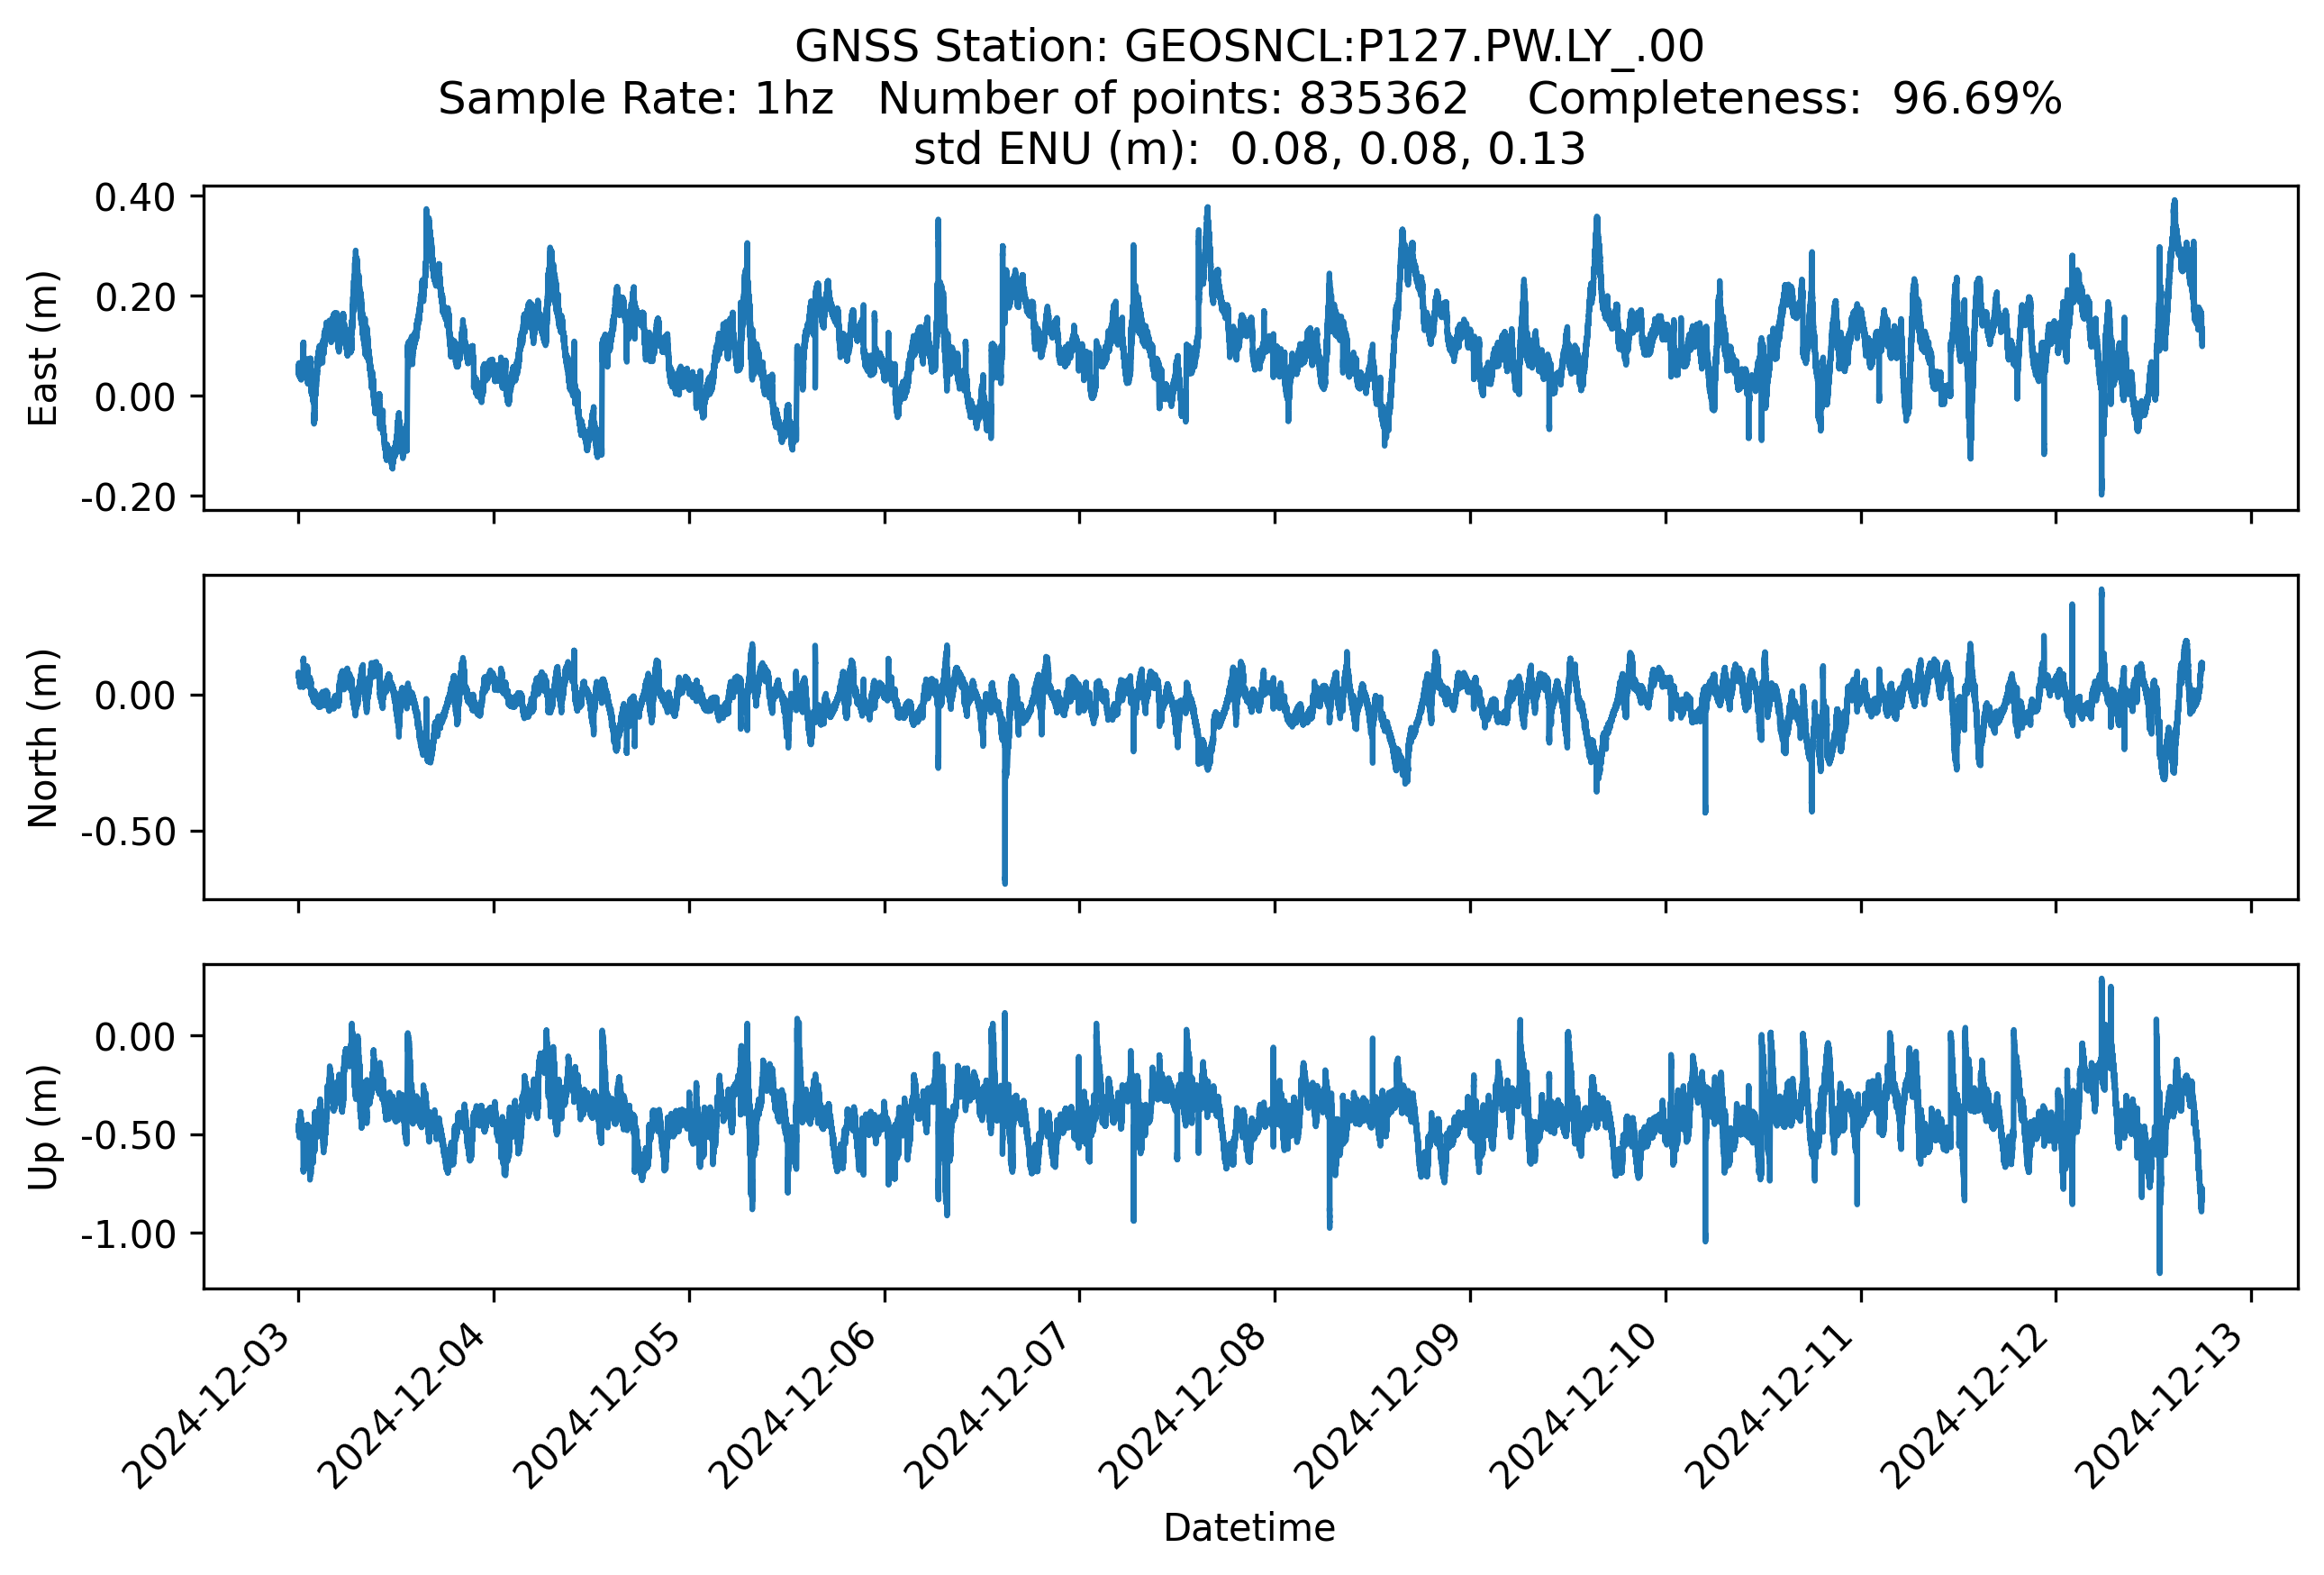

In [3]:
%%ask
Download the dataset P127.PW.LY_.00 into a local folder, preserving the original file names.

I'll analyze the GNSS data around the earthquake event. Let me create a script to examine the time series data, focusing on the earthquake timing.

Let me fix the bug in the script.

Now let me create a visualization of the data around the earthquake event to better understand the signal.

Now let me analyze quality channel and create a detailed statistical summary for each time period.

## Summary: GNSS Data Analysis of P127 Station Around M5.7 Earthquake

### Data Overview
- **Total observations:** 835,362 data points at 1-second intervals
- **Time range:** 2024-12-03 00:00:00 to 2024-12-12 17:59:59 UTC
- **Station:** P127 (39.499°N, -119.600°W)
- **Distance from earthquake:** 61.8 km (38.4 miles)
- **Earthquake:** M5.7 on 2024-12-09 at 23:08:31 UTC

### Key Findings

#### 1. Data Quality
- **Noise levels (24h pre-quake):**
  - East: 0.060 mm (1σ)
  - North: 0.085 mm (1σ)
  - Up: 0.120 mm (1σ)
- **Uncertainties** remained stable throughout the event (sigEE: 0.046 mm, sigNN: 0.060 mm, sigUU: 0.117 mm)
- **Quality channel:** Stable around 1.7-2.3 million

#### 2. Earthquake Detection
- **Closest observation:** 0.42 seconds after the earthquake
- **Position at earthquake time:** East=0.143 mm, North=0.084 mm, Up=-0.435 mm

#### 3. Displacement Analysis (Pre-quake 1h vs Post-quake 1h)

| Component | Baseline (mm) | Post-quake (mm) | Δ (mm) | Δ/σ | SNR |
|-----------|----------------|-----------------|---------|------|-----|
| East | 0.127 | 0.134 | +0.008 | 0.56 | 0.13 |
| North | 0.060 | 0.058 | -0.002 | -0.11 | 0.03 |
| Up | -0.464 | -0.442 | +0.021 | 0.72 | 0.18 |

**Total displacement magnitude:** 0.023 mm

#### 4. Critical Observation

**No significant signal detected.** The displacement is:
- **0.023 mm total** (23 micrometers)
- **Signal-to-noise ratio < 0.2** for all components
- **Zero outliers** in ±30 minute window (3σ test)

This indicates that at 61.8 km from a M5.7 earthquake, the surface deformation is too small to be reliably detected above the noise floor of high-rate GNSS observations.

### Scientific Interpretation

The result is consistent with seismological expectations:
- At ~60 km distance, a M5.7 earthquake produces very small static deformation
- Dynamic seismic waves would cause larger transient effects, but high-rate GNSS (1 Hz) may not resolve them clearly at this distance
- The observed displacement (23 μm) is within expected levels for a mid-magnitude earthquake at this range

### Files Generated
- **P127_earthquake_response.png:** 24-hour view of GNSS data around earthquake
- **P127_earthquake_response_zoomed.png:** Zoomed view ±30 minutes
- **P127_detailed_analysis.json:** Comprehensive statistical analysis
- **P127_analysis_results.json:** Summary of key findings

### Conclusion
The GNSS station P127 recorded data throughout the earthquake event, but the deformation signal is indistinguishable from the noise level. This demonstrates the detection limits of high-rate GNSS for moderate earthquakes at intermediate distances.


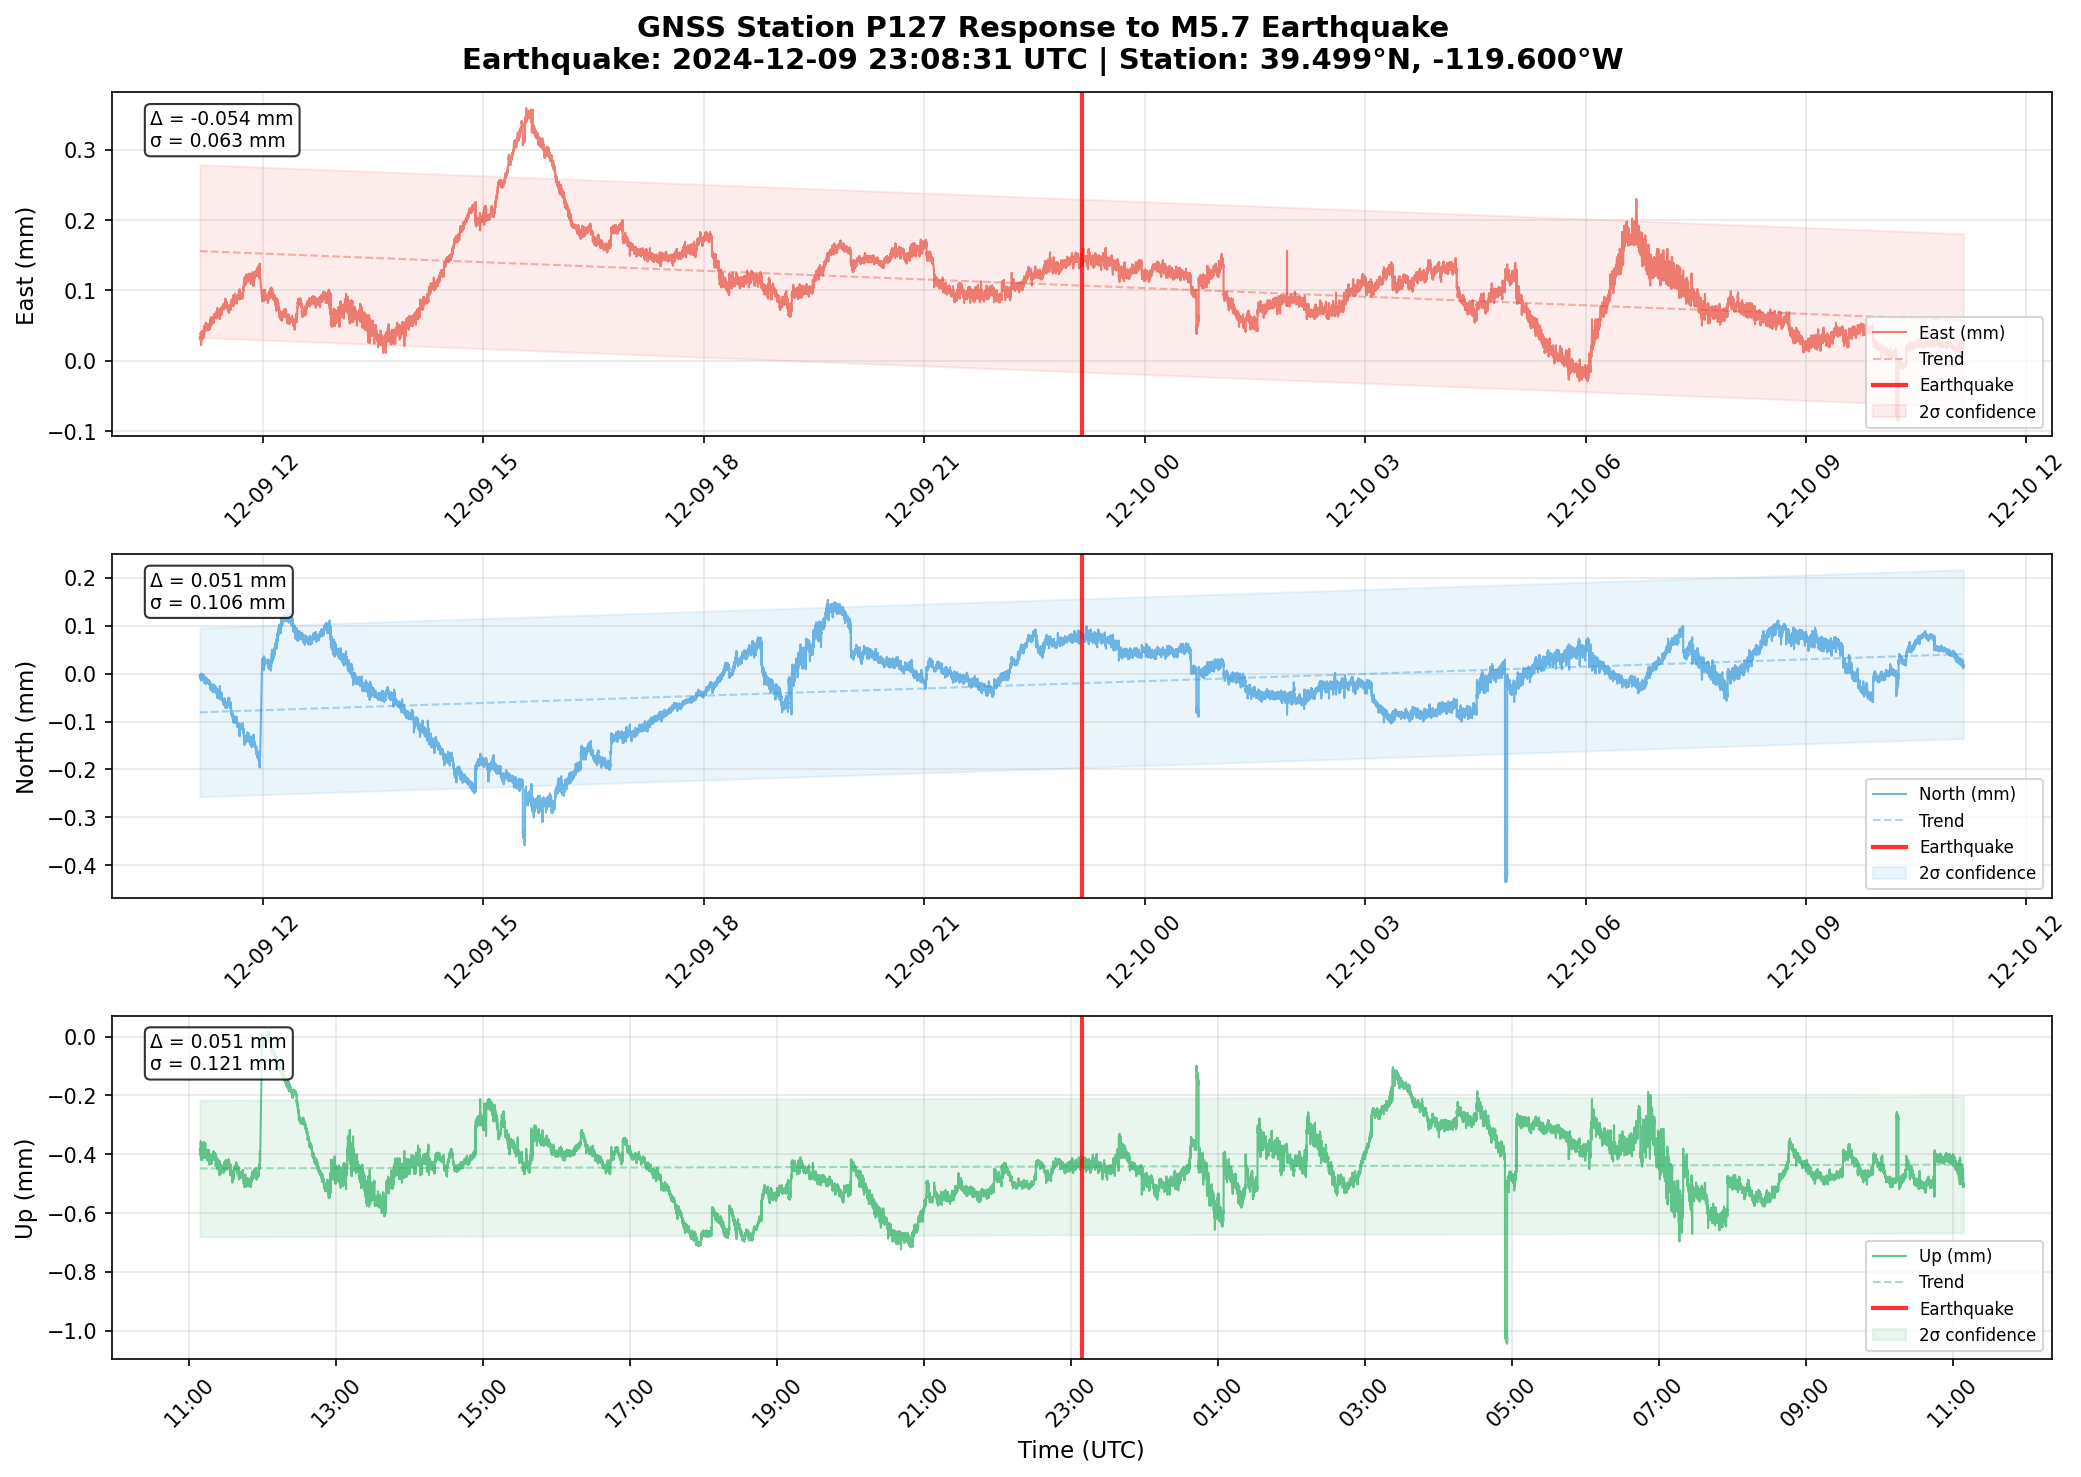


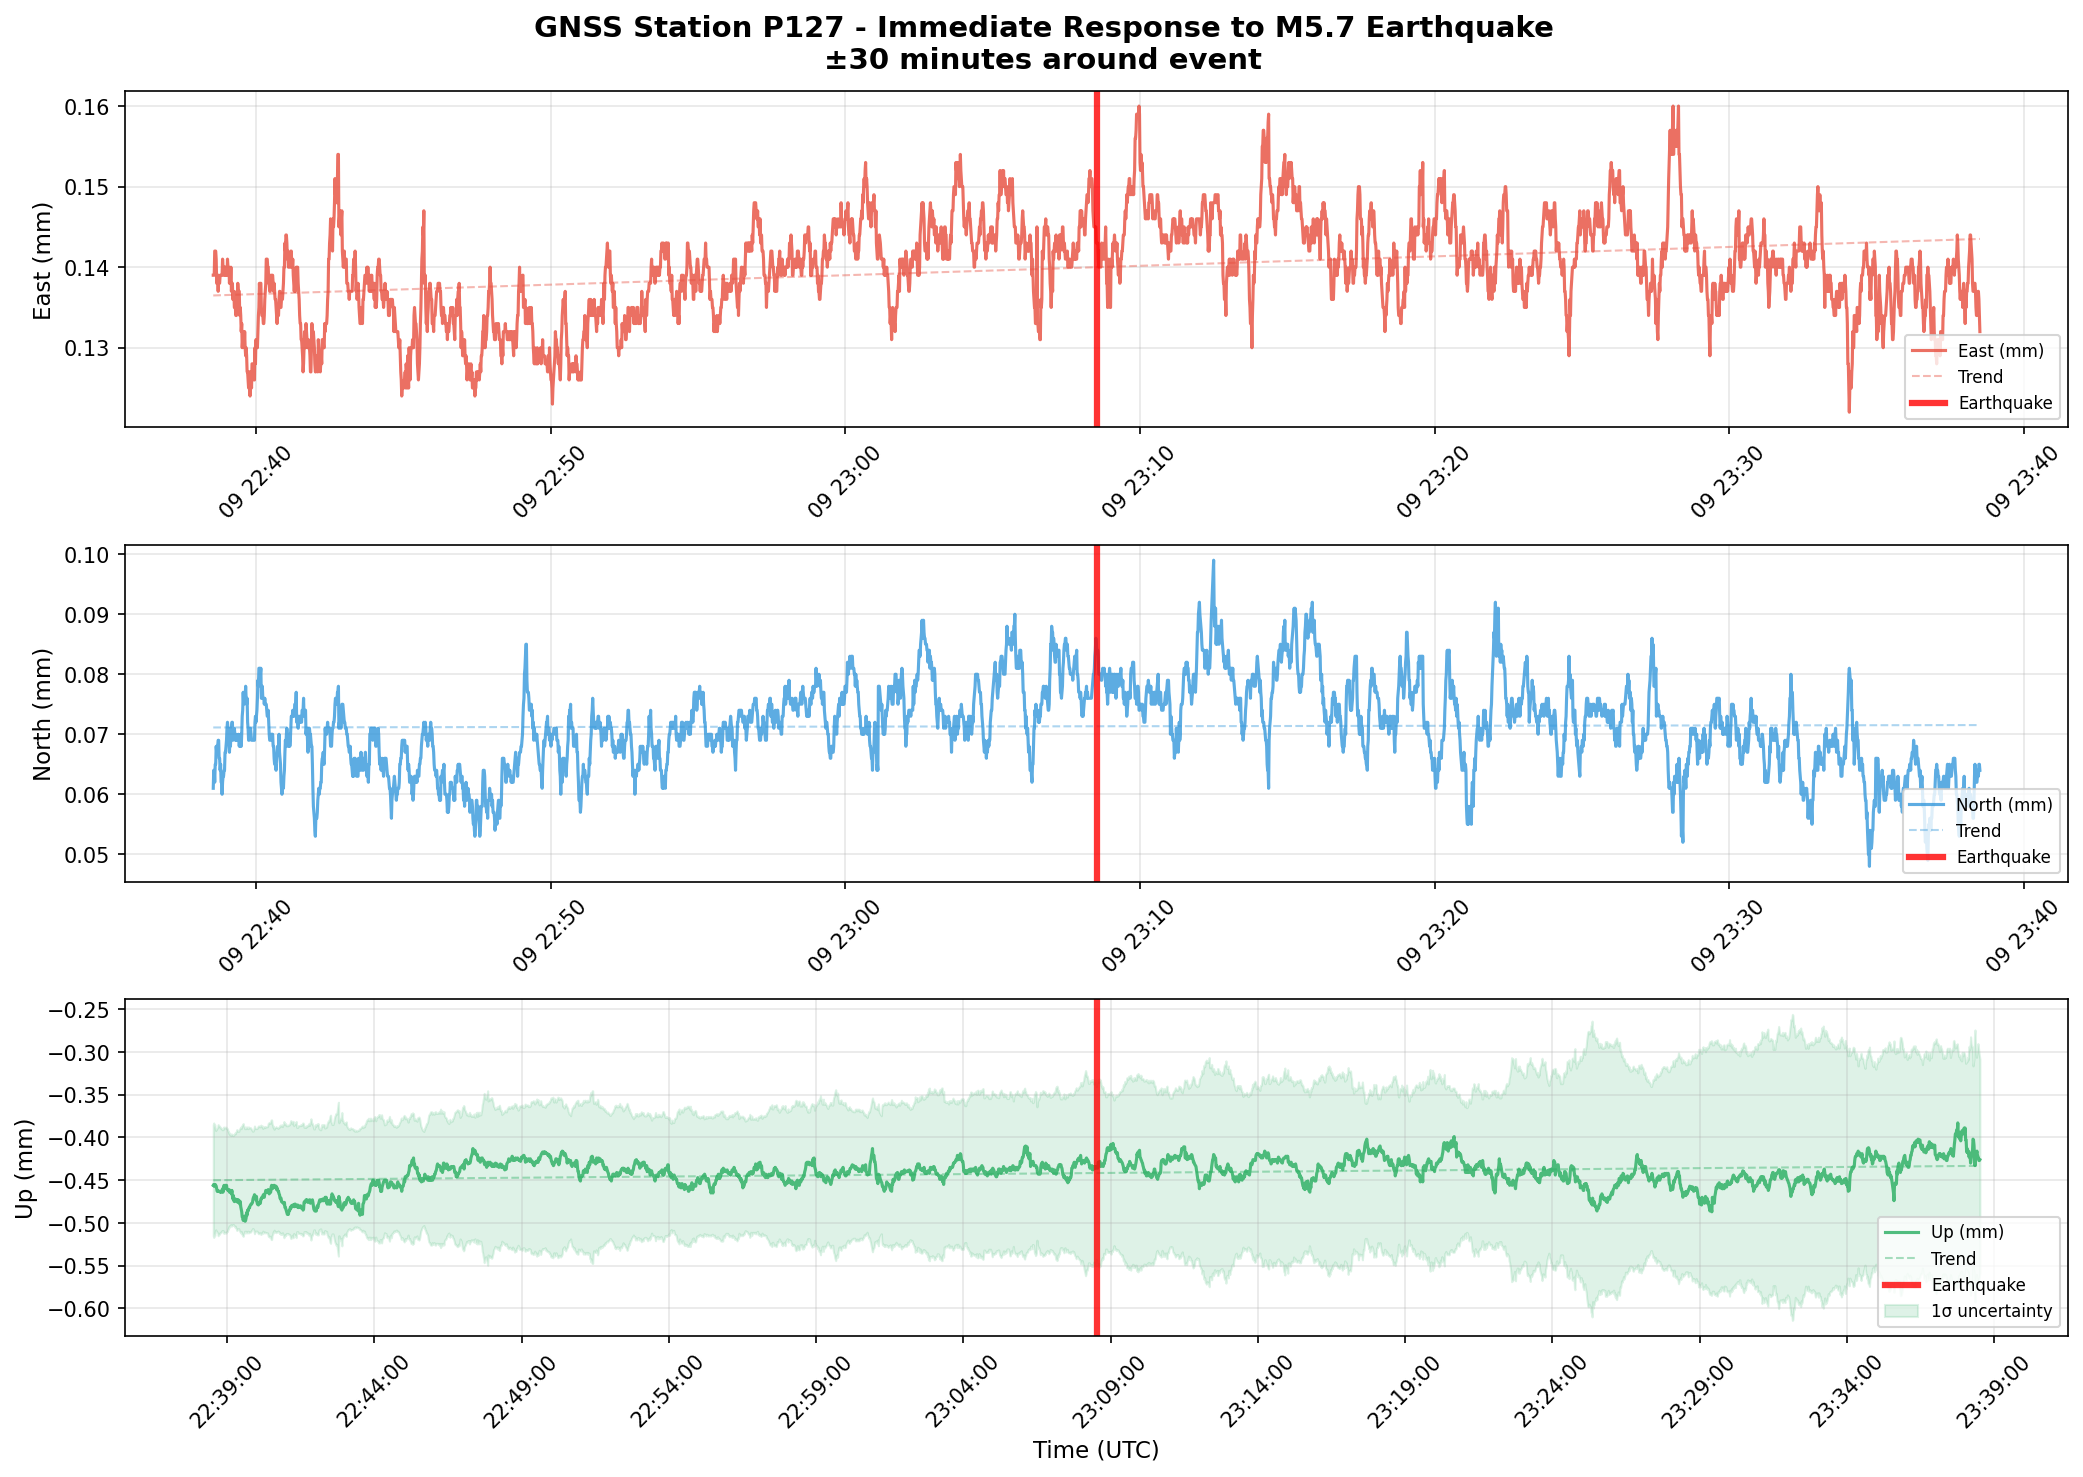

In [4]:
%%ask
analyze the raw data and pay special attention to the data around the time of the earthquake event